In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import binomtest
import plotly.express as px
import statsmodels.api as sm

all_data = pd.read_csv('/Users/kyleleighton/Downloads/Life-Expectancy-and-GDP-Starter/all_data.csv')

In [120]:
print(all_data.describe(include='all'))
print(all_data.Country.unique())
print(all_data.head())
#renaming column for cleaner references in code
all_data.rename(columns={'Life expectancy at birth (years)':'life_expectancy'})

       Country         Year           GDP  life_expectancy
count       96    96.000000  9.600000e+01        96.000000
unique       6          NaN           NaN              NaN
top      Chile          NaN           NaN              NaN
freq        16          NaN           NaN              NaN
mean       NaN  2007.500000  3.880499e+12        72.789583
std        NaN     4.633971  5.197561e+12        10.672882
min        NaN  2000.000000  4.415703e+09        44.300000
25%        NaN  2003.750000  1.733018e+11        74.475000
50%        NaN  2007.500000  1.280220e+12        76.750000
75%        NaN  2011.250000  4.067510e+12        78.900000
max        NaN  2015.000000  1.810000e+13        81.000000
['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']
  Country  Year           GDP  life_expectancy
0   Chile  2000  7.786093e+10             77.3
1   Chile  2001  7.097992e+10             77.3
2   Chile  2002  6.973681e+10             77.8
3   Chile  2003  7.564346e+10

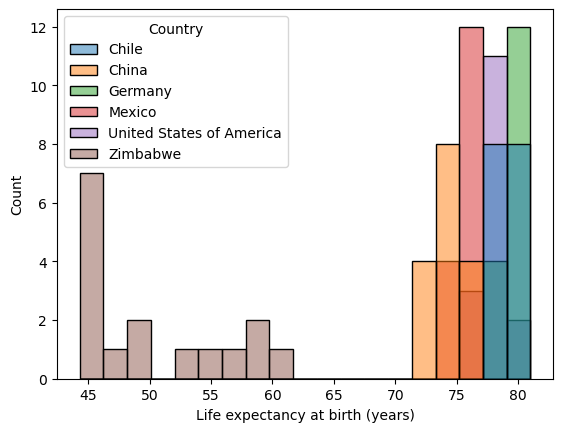

<Figure size 640x480 with 0 Axes>

In [48]:
#checking the distribution of life expectancies over the different countries
sns.histplot(x='life_expectancy', data=all_data, hue='Country')
plt.show()
plt.clf()

These charts illustrate a general correlation between GDP and life expectancy, but not a perfect one.
Wealthier countries tend to live longer, but diminishing returns set in once basic healthcare and 
infrastructure are in place. For developing countries, targeted public health measures (like in Zimbabwe) 
can drive dramatic improvements even without strong economic growth.


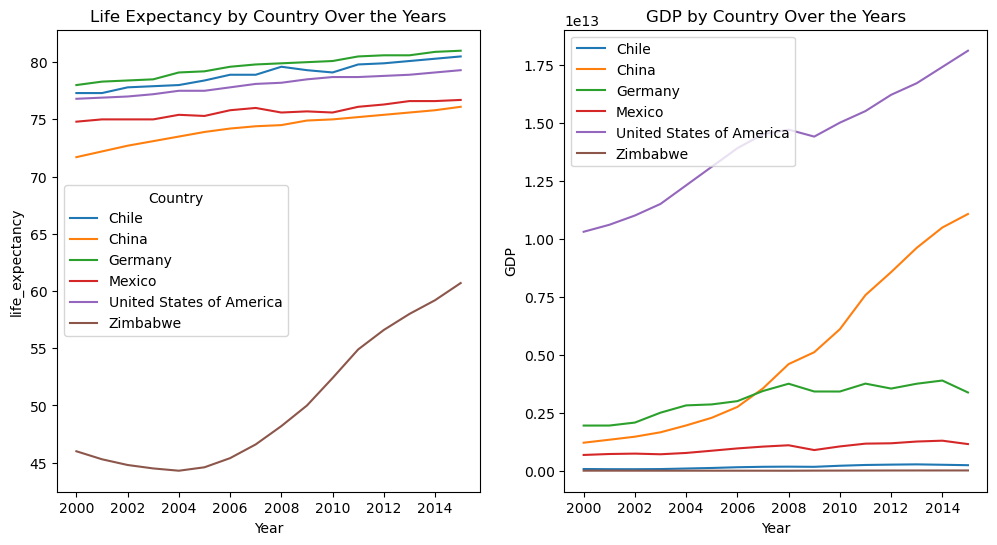

In [124]:
#sizing and creating side by side charts
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.lineplot(x='Year', y='life_expectancy', hue='Country', data=all_data)
plt.title('Life Expectancy by Country Over the Years')
plt.subplot(1,2,2)
sns.lineplot(x='Year', y='GDP', hue='Country', data=all_data)
plt.legend(loc='upper left')
plt.title('GDP by Country Over the Years')
print(f'These charts illustrate a general correlation between GDP and life expectancy, but not a perfect one.'
       f'\nWealthier countries tend to live longer, but diminishing returns set in once basic healthcare and'
       f' \ninfrastructure are in place. For developing countries, targeted public health measures (like in Zimbabwe) '
       f'\ncan drive dramatic improvements even without strong economic growth.')

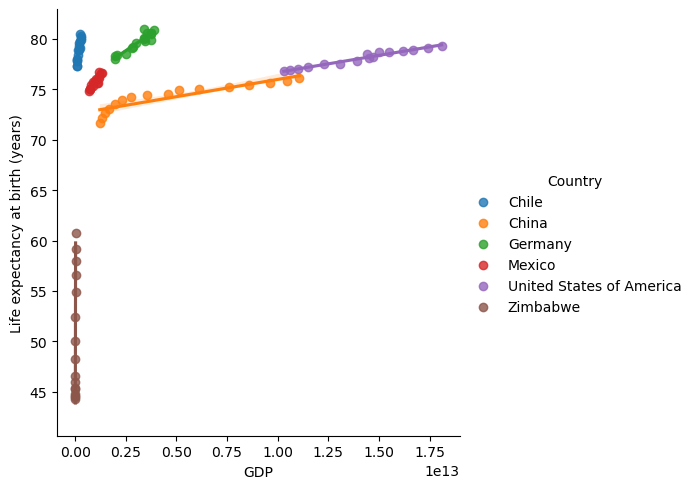

In [31]:
sns.lmplot(x='GDP', y='life_expectancy', data=all_data, hue='Country', x_jitter=True)

Intercept   -320.097206
Year           0.197971
dtype: float64
For countries with >70 year baseline life expectancy.
The slope (~0.20) suggests life expectancy increases by about 0.2 years
each year, indicating a steady upward trend.


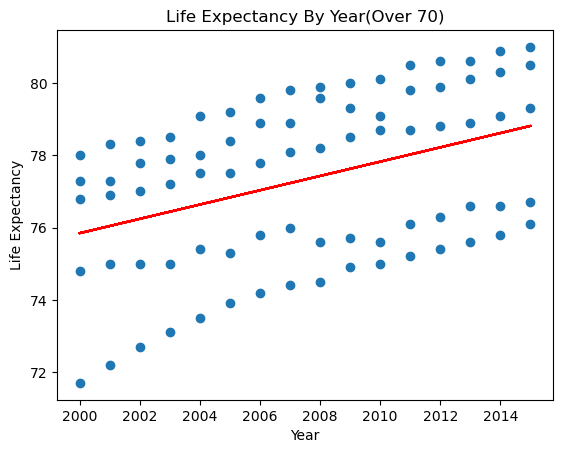

In [126]:
#filtering data to only life expectancies over 70 years
over_70 = all_data[all_data['life_expectancy'] > 70]
# fitting a simple linear regression model to estimate how life expectancy changes over time
# changes over time for countries with >70 year baseline life expectancy. 
# The slope (~0.20) suggests life expectancy increases by about 0.2 years 
# each year, indicating a steady upward trend.
model = sm.OLS.from_formula('life_expectancy ~ Year', data=over_70)
results = model.fit()
print(results.params)
y = 0.197971*over_70['Year'] + -320.097206
#creating graph
plt.scatter(x='Year', y='life_expectancy', data=over_70)
plt.plot(over_70['Year'], y, color='red')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy By Year(Over 70)')
print(f'For countries with >70 year baseline life expectancy.' 
f'\nThe slope (~0.20) suggests life expectancy increases by about 0.2 years' 
f'\neach year, indicating a steady upward trend.')

Intercept   -2264.140441
Year            1.152794
dtype: float64
For countries with <65 year baseline life expectancy.
The slope (~1.15) suggests life expectancy increases by about 1.15 years
each year, which is a noticably steeper slope, indicating
global health convergence, where lower-baseline countries are catching up faster.


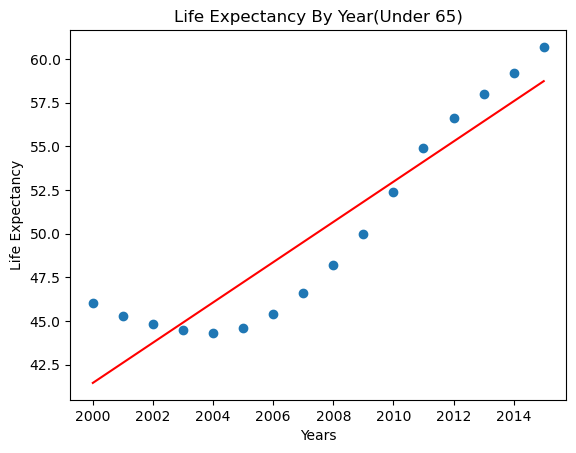

In [130]:
#filtering data to only life expectancies under 65 years
under_65 = all_data[all_data['life_expectancy'] < 65]
# fitting a simple linear regression model to estimate how life expectancy
# changes over time for countries with <65 year baseline life expectancy. 
model_2 = sm.OLS.from_formula('life_expectancy ~ Year', data=under_65)
results_2 = model_2.fit()
print(results_2.params)
y_2 = 1.152794*under_65['Year'] + -2264.140441
#creating graph
plt.scatter(x='Year', y='life_expectancy', data=under_65)
plt.plot(under_65['Year'],y_2, color='red')
plt.xlabel('Years')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy By Year(Under 65)')
print(f'For countries with <65 year baseline life expectancy.' 
f'\nThe slope (~1.15) suggests life expectancy increases by about 1.15 years' 
f'\neach year, which is a noticably steeper slope, indicating'
f'\nglobal health convergence, where lower-baseline countries are catching up faster.')

Text(0.5, 1.0, 'Average Life Expectancy by Country')

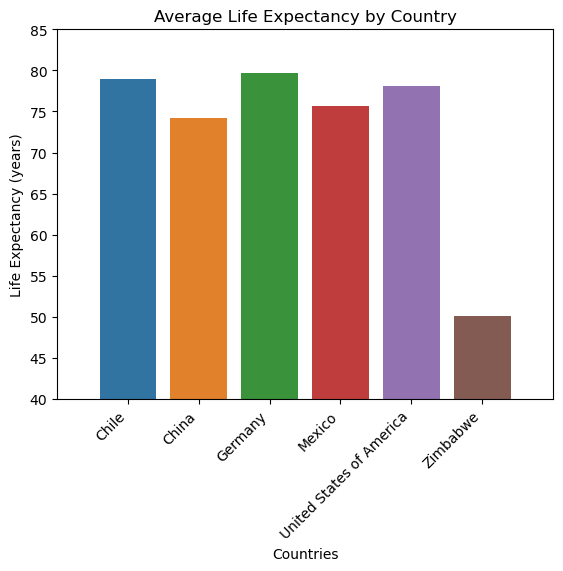

In [145]:
# finding the average life expectancy by country 
avg_life_expectancy = all_data.groupby('Country').life_expectancy.mean()
avg_life = avg_life_expectancy.reset_index()
avg_life.columns = ['country', 'life_expectancy']
#creating a bar chart with the average life expectancy by country
sns.barplot(data=avg_life, x='country', y='life_expectancy', hue='country')
plt.axis([-1,6,40,85])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Countries')
plt.ylabel('Life Expectancy (years)')
plt.title('Average Life Expectancy by Country')
